In [56]:
import tensorflow as tf
from stardist import gputools_available
from glob import glob
import os
from csbdeep.utils import Path, normalize
from stardist import fill_label_holes, random_label_cmap, calculate_extents, gputools_available
from stardist.matching import matching, matching_dataset
from stardist.models import Config2D, StarDist2D, StarDistData2D
import shutil
from functions import *

In [57]:
# pth_HE_tiles = r'\\10.99.68.178\andreex\students\Donald Monkey fetus\stardist\training_and_testing_monkey_12_7_23\training\images'
# pth_mask_tiles = r'\\10.99.68.178\andreex\students\Donald Monkey fetus\stardist\training_and_testing_monkey_12_7_23\training\masks'
pth0=r'\\10.162.80.16\Andre\data\Stardist\BIG PANIN model Rita\training_8_10_2024'
pth_HE_tiles = os.path.join(pth0, 'HEs')
pth_mask_tiles =  os.path.join(pth0, 'masks')
date = '_8_10_24'
nm='Big_PANIN_model'
outpthmodel = os.path.join(pth0, f'{nm}{date}')
os.makedirs(outpthmodel, exist_ok=True)

In [58]:
# define hyperparameters, name model
lr = 0.001
epochs = 400
patience = 40
ratio_validation_tiles = 0.4 
outnm = nm + date + '_lr_' + str(lr) + '_epochs_' + str(epochs) + '_pt_' + str(patience)
print(outnm)
pth_log_train = fr"{outpthmodel}\{outnm}"
os.makedirs(pth_log_train, exist_ok=True)

Big_PANIN_model_8_10_24_lr_0.001_epochs_400_pt_40


In [59]:
HE_tiles = read_tiles(pth_HE_tiles)
masks = read_masks(pth_mask_tiles)
tiles_train, masks_train, tiles_val, masks_val = split_train_val_set(HE_tiles, masks, ratio_validation_tiles)
# add flips and rotations to the images/masks pairs
HE_train_aug, masks_train_aug = augment_tiles(tiles_train, masks_train)
# normalize H&E images by dividing by 255
HE_train_aug = normalize_images(HE_train_aug)
tiles_val = normalize_images(tiles_val)

print(f'{len(HE_train_aug)}')
print(f'{len(masks_train_aug)}')
print(f'{len(tiles_val)}')
print(f'{len(masks_val)}')

456
456
38
38


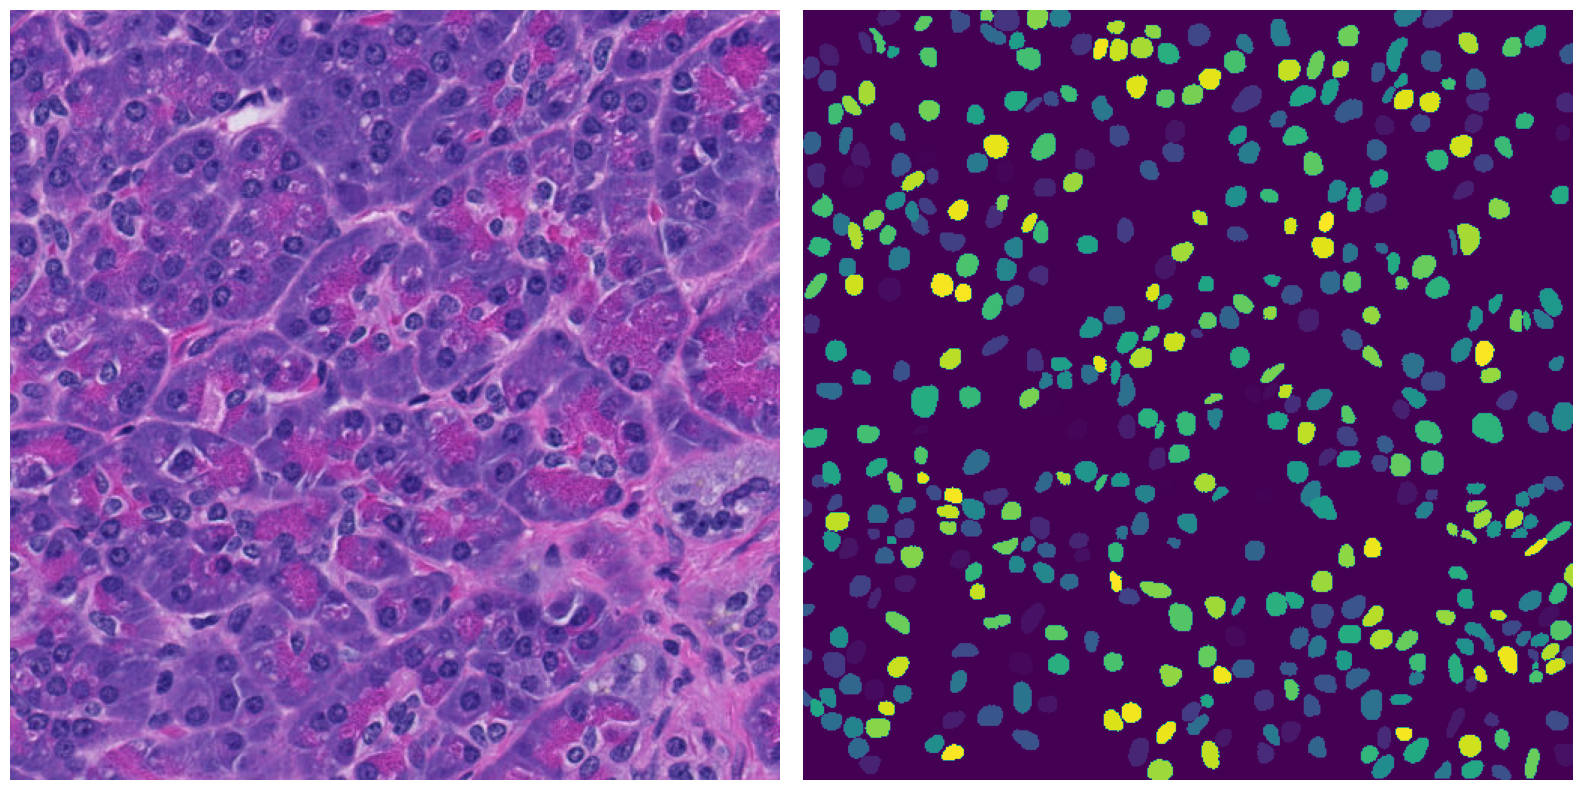

In [60]:
# look at training data
i = 100
show_HE_and_segmented(HE_train_aug[i], masks_train_aug[i])

In [61]:
# Check for GPU availability
print("GPU is available" if tf.config.list_physical_devices('GPU') else "GPU is not available")
print(tf.__version__)

# Define the configuration
conf = Config2D(
    n_rays=32,
    grid=(2,2),
    use_gpu=gputools_available(),
    n_channel_in=1 if tiles_train[0].ndim == 2 else tiles_train[0].shape[-1]
)

GPU is available
2.10.1


In [62]:
# configure model
# model = load_published_he_model(outpthmodel, outnm)
model_path = r'\\10.162.80.16\Andre_expansion\data\Stardist\PDAC model\models\lea_model'
offshoot_model_pth = os.path.join(model_path,'offshoot_model')

model = load_model(model_path)
model.config.train_learning_rate = lr
model.config.train_patch_size = (256,256)
model.config.train_reduce_lr={'factor': 0.5, 'patience': patience, 'min_delta': 0}
model.train(HE_train_aug, masks_train_aug, validation_data=(tiles_val, masks_val), epochs=epochs, steps_per_epoch=100)
model.optimize_thresholds(tiles_val, masks_val)

shutil.copytree(offshoot_model_pth, pth_log_train, dirs_exist_ok=True)

pth_log = glob(os.path.join(pth_log_train,'logs','train','*.v2'))[0]
loss = get_loss_data(str(pth_log), pth_log_train)

Using default values: prob_thresh=0.5, nms_thresh=0.4.
Overriding defaults: Thresholds(prob=0.4872387821889486, nms=0.3) 
Epoch 1/400
100/100 [==============================] - 7s 65ms/step - loss: 0.3865 - prob_loss: 0.1469 - dist_loss: 1.1981 - prob_kld: 0.0532 - dist_relevant_mae: 1.1978 - dist_relevant_mse: 3.4754 - dist_dist_iou_metric: 0.7029 - val_loss: 0.4056 - val_prob_loss: 0.1628 - val_dist_loss: 1.2142 - val_prob_kld: 0.0555 - val_dist_relevant_mae: 1.2138 - val_dist_relevant_mse: 3.8045 - val_dist_dist_iou_metric: 0.7046 - lr: 0.0010
Epoch 2/400
100/100 [==============================] - 4s 39ms/step - loss: 0.3738 - prob_loss: 0.1425 - dist_loss: 1.1566 - prob_kld: 0.0487 - dist_relevant_mae: 1.1562 - dist_relevant_mse: 3.2449 - dist_dist_iou_metric: 0.7110 - val_loss: 0.4293 - val_prob_loss: 0.1704 - val_dist_loss: 1.2947 - val_prob_kld: 0.0631 - val_dist_relevant_mae: 1.2943 - val_dist_relevant_mse: 3.9185 - val_dist_dist_iou_metric: 0.6843 - lr: 0.0010
Epoch 3/400
100/

NMS threshold = 0.5:  75%|███████▌  | 15/20 [00:19<00:06,  1.32s/it, 0.526 -> 0.725]


Using optimized values: prob_thresh=0.528729, nms_thresh=0.3.
Saving to 'thresholds.json'.


In [63]:
outpthmodel

'\\\\10.162.80.16\\Andre\\data\\Stardist\\BIG PANIN model Rita\\training_8_10_2024\\Big_PANIN_model_8_10_24\\Big_PANIN_model_8_10_24_lr_0.001_epochs_400_pt_40'